In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
orders = pd.read_csv("dataset/olist_orders_dataset.csv")
items = pd.read_csv("dataset/olist_order_items_dataset.csv")
products = pd.read_csv("dataset/olist_products_dataset.csv")
payments = pd.read_csv("dataset/olist_order_payments_dataset.csv")
customers = pd.read_csv("dataset/olist_customers_dataset.csv")

In [41]:
#Чистка данных
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [59]:
#Агрегируем payments
payments_agg = payments.groupby("order_id", as_index=False)["payment_value"].sum()

In [60]:
#Cоединяем с orders
orders_payments = orders.merge(payments_agg, on="order_id", how="left")

In [47]:
#Общая выручка
round(orders_payments["payment_value"].sum(),3)

np.float64(16008872.12)

In [48]:
#Средний чек
round(orders_payments["payment_value"].mean(),3)

np.float64(160.99)

In [49]:
#Кол-во заказов
orders_payments["order_id"].nunique()

99441

In [61]:
#Выручка по товарам
items_agg = items.groupby("product_id", as_index=False).agg({
    "price": "sum",
    "order_id": "count"
})

items_agg.rename(columns={
    "price": "revenue",
    "order_id": "orders_count"
}, inplace=True)

In [52]:
items_agg.head()

,product_id,revenue,orders_count
0,00066f42aeeb9f3007548bb9d3f33c38,101.65,1
1,00088930e925c41fd95ebfe695fd2655,129.90,1
2,0009406fd7479715e4bef61dd91f2462,229.00,1
3,000b8f95fcb9e0096488278317764d19,117.80,2
4,000d9be29b5207b54e86aa1b1ac54872,199.00,1


In [53]:
#Объединяем items + products
items_products = items.merge(products, on="product_id", how="left")

In [54]:
#Выручка по категориям
category_agg = items_products.groupby("product_category_name", as_index=False).agg({
    "price": "sum",
    "product_id": "count"
})

In [55]:
category_agg.rename(columns={
    "price": "revenue",
    "product_id": "items_sold"
}, inplace=True)

In [56]:
#Cортируем по выручке
category_agg = category_agg.sort_values("revenue", ascending=False)

In [57]:
category_agg.head(10)

,product_category_name,revenue,items_sold
11,beleza_saude,1258681.34,9670
66,relogios_presentes,1205005.68,5991
13,cama_mesa_banho,1036988.68,11115
32,esporte_lazer,988048.97,8641
44,informatica_acessorios,911954.32,7827
54,moveis_decoracao,729762.49,8334
26,cool_stuff,635290.85,3796
72,utilidades_domesticas,632248.66,6964
8,automotivo,592720.11,4235
40,ferramentas_jardim,485256.46,4347


In [62]:
#ABC-анализ категорий
#Cортируем категории по выручке
abc = category_agg.sort_values("revenue", ascending=False).copy()

In [63]:
#Доля выручки
abc["revenue_share"] = abc["revenue"] / abc["revenue"].sum()

In [64]:
abc["cum_share"] = abc["revenue_share"].cumsum()

In [65]:
#Присваиваем ABC-класс
def abc_class(x):
    if x <= 0.8:
        return "A"
    elif x <= 0.95:
        return "B"
    else:
        return "C"

abc["ABC"] = abc["cum_share"].apply(abc_class)

In [66]:
abc.head(20)

,product_category_name,revenue,items_sold,revenue_share,cum_share,ABC
11,beleza_saude,1258681.34,9670,0.093847,0.093847,A
66,relogios_presentes,1205005.68,5991,0.089845,0.183691,A
13,cama_mesa_banho,1036988.68,11115,0.077317,0.261009,A
32,esporte_lazer,988048.97,8641,0.073668,0.334677,A
44,informatica_acessorios,911954.32,7827,0.067995,0.402672,A
54,moveis_decoracao,729762.49,8334,0.054411,0.457083,A
26,cool_stuff,635290.85,3796,0.047367,0.504450,A
72,utilidades_domesticas,632248.66,6964,0.047140,0.551590,A
8,automotivo,592720.11,4235,0.044193,0.595783,A
40,ferramentas_jardim,485256.46,4347,0.036180,0.631963,A


In [67]:
#СЕЗОННОСТЬ ПРОДАЖ\
orders_payments.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62


In [68]:
#Месяц заказа
orders_payments["month"] = orders_payments["order_purchase_timestamp"].dt.to_period("M")

In [69]:
#Выручка по месяцам
monthly_revenue = orders_payments.groupby("month", as_index=False).agg({
    "payment_value": "sum"
})

In [70]:
monthly_revenue = monthly_revenue.sort_values("month")

In [71]:
monthly_revenue

,month,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


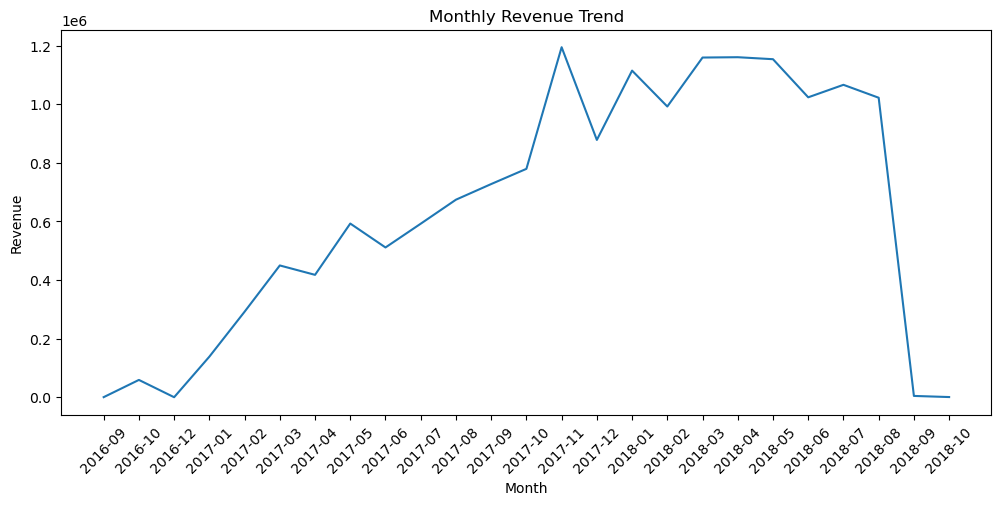

In [73]:
#Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue["month"].astype(str), monthly_revenue["payment_value"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

In [75]:
orders_payments.to_csv("orders_payments.csv", index=False)
category_agg.to_csv("category_agg.csv", index=False)
abc.to_csv("abc.csv", index=False)